# El problema de la flor de Iris

En este cuaderno exploraremos el flujo completo de un proyecto de aprendizaje automático: desde la lectura de datos hasta la validación de modelos, utilizando el clásico conjunto de datos de la flor de Iris. Nuestro objetivo será predecir la especie de una flor de Iris basándonos en las medidas de sus sépalos y pétalos.

In [13]:
# Importación de librerías esenciales
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Herramientas de scikit-learn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 1. Lectura de Datos
Utilizaremos `pandas` exclusivamente para descargar y leer nuestro conjunto de datos en formato CSV desde un repositorio público.

In [14]:
# URL pública con el dataset de Iris
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

# Lectura del CSV
df = pd.read_csv(url)


# Algunas muestras del dataset
df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
95,5.7,3.0,4.2,1.2,versicolor
111,6.4,2.7,5.3,1.9,virginica
85,6.0,3.4,4.5,1.6,versicolor
133,6.3,2.8,5.1,1.5,virginica
118,7.7,2.6,6.9,2.3,virginica
147,6.5,3.0,5.2,2.0,virginica
34,4.9,3.1,1.5,0.2,setosa
104,6.5,3.0,5.8,2.2,virginica
14,5.8,4.0,1.2,0.2,setosa
97,6.2,2.9,4.3,1.3,versicolor


In [15]:
# Extraemos las características (X) y las etiquetas (y) como arreglos de numpy
X_raw = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
Y_raw = df['species'].values

print("Dimensiones de X: {} datos y {} atributos/dato".format(X_raw.shape[0], X_raw.shape[1]))

etiquetas= np.unique(Y_raw)

print("La última columna tiene el tipo de flor:\nHay {} tipos de flor: {}".format(len(etiquetas), etiquetas))

Dimensiones de X: 150 datos y 4 atributos/dato
La última columna tiene el tipo de flor:
Hay 3 tipos de flor: ['setosa' 'versicolor' 'virginica']


In [16]:

print('Información básica del dataset: ')
df.info()


Información básica del dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [17]:

print('Estadísticos básicos: ')
df.describe()


Estadísticos básicos: 


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. Análisis Exploratorio de Datos (EDA)
Antes de entrenar cualquier modelo, debemos entender nuestros datos. Vamos a visualizar cómo se distribuyen las especies en función de dos de sus características: la longitud y el ancho del pétalo.

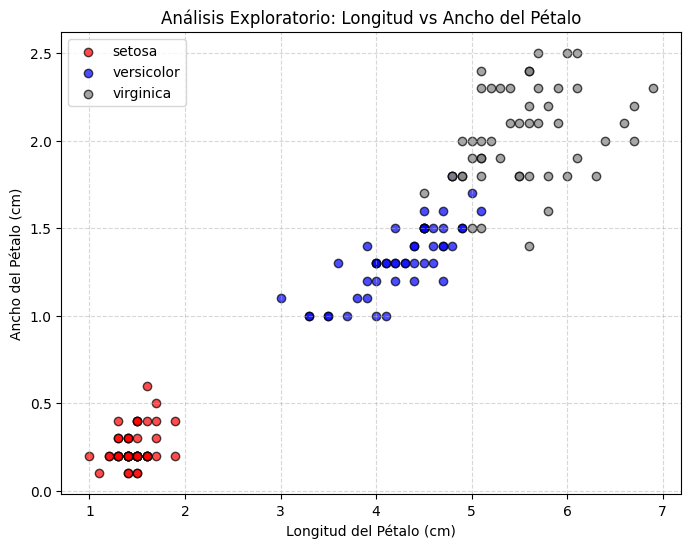

In [18]:
plt.figure(figsize=(8, 6))

especies= df['species'].unique()
colores= ['red', 'blue', 'gray']

for especie, color in zip(especies, colores):
    # Filtramos las filas correspondientes a la especie actual
    idx = (Y_raw == especie)
    # Imprimimos columnas 2 vs 3 (características del pétalo)
    plt.scatter(X_raw[idx, 2], X_raw[idx, 3], label=especie, color=color, alpha=0.7, edgecolors='k')

plt.title('Análisis Exploratorio: Longitud vs Ancho del Pétalo')
plt.xlabel('Longitud del Pétalo (cm)')
plt.ylabel('Ancho del Pétalo (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

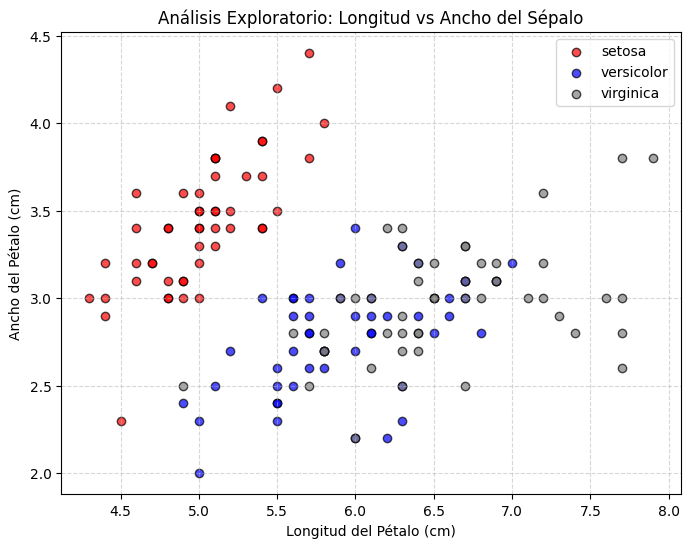

In [19]:
plt.figure(figsize=(8, 6))

for especie, color in zip(especies, colores):
    # Filtramos las filas correspondientes a la especie actual
    idx = (Y_raw == especie)
    # Imprimimos columnas 0 vs 1 (características del sétalo)
    plt.scatter(X_raw[idx, 0], X_raw[idx, 1], label=especie, color=color, alpha=0.7, edgecolors='k')

plt.title('Análisis Exploratorio: Longitud vs Ancho del Sépalo')
plt.xlabel('Longitud del Pétalo (cm)')
plt.ylabel('Ancho del Pétalo (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

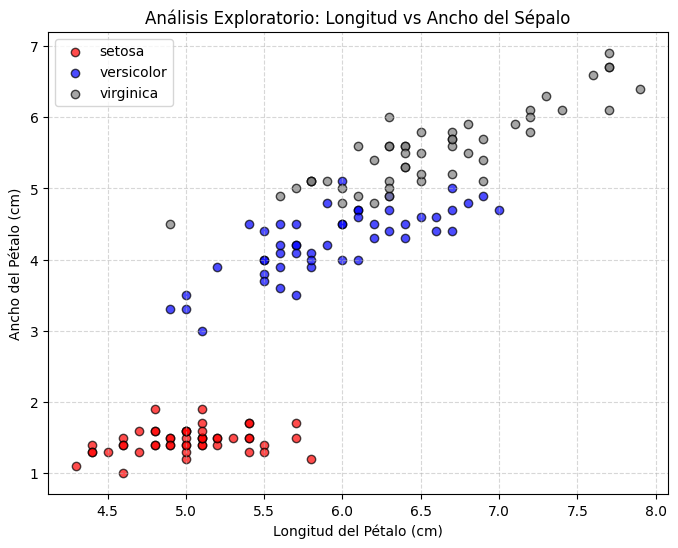

In [20]:
plt.figure(figsize=(8, 6))

for especie, color in zip(especies, colores):
    # Filtramos las filas correspondientes a la especie actual
    idx = (Y_raw == especie)
    # Imprimimos columnas 0 vs 2 (largo del sétalo/pétalo)
    plt.scatter(X_raw[idx, 0], X_raw[idx, 2], label=especie, color=color, alpha=0.7, edgecolors='k')

plt.title('Análisis Exploratorio: Longitud vs Ancho del Sépalo')
plt.xlabel('Longitud del Pétalo (cm)')
plt.ylabel('Ancho del Pétalo (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

<h1><b> Espera un momento ... <b></h1>

Estas son (no) muchas gráficas. Visualizarlo todo es incómodo. Mejor usamos un subplot...

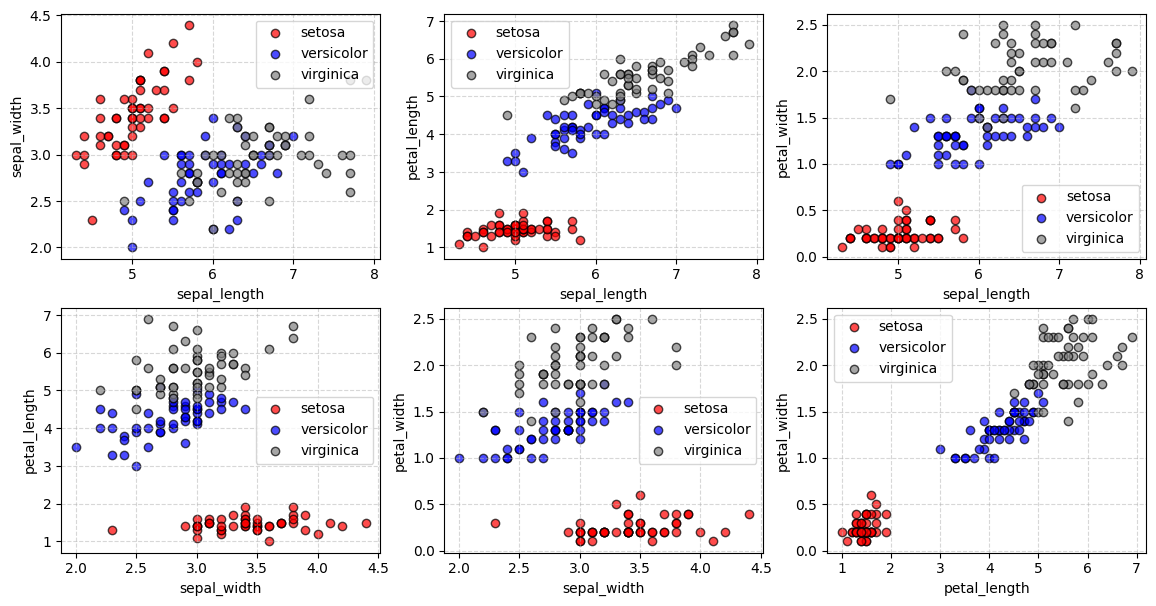

In [21]:
from itertools import combinations

columnas= df.columns[:-1] # Sólo atributos
columnas_idx= np.arange(len(columnas)) # Índices de las columnas

# Combinaciones de todas con todas las columnas (sin permutar)
plt.figure(figsize=(14, 7))
for i, (col1, col2) in enumerate(combinations(columnas_idx, 2), 1):
  plt.subplot(2, 3, i) # Cada par (col1, col2) a un subplot
  for especie, color in zip(especies, colores):
    idx = (Y_raw == especie)
    plt.scatter(X_raw[idx, col1], X_raw[idx, col2], label=especie, color=color, alpha=0.7, edgecolors='k')

    plt.xlabel(columnas[col1])
    plt.ylabel(columnas[col2])
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5) # Ponerlo "bonito"
plt.show()


## 3. Preprocesamiento de Datos
Las máquinas no entienden de texto (como "setosa"), entienden de números. Además, muchos algoritmos funcionan mejor si las características tienen una escala similar (media 0 y varianza 1).

In [22]:
# 3.1 Codificación de etiquetas (de texto a números: 0, 1, 2)
encoder = LabelEncoder()
y = encoder.fit_transform(Y_raw)

print('Datos originales: ', Y_raw)
print('Datos transformados: ', y)

Datos originales:  ['setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa'
 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa'
 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa'
 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa'
 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa'
 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa'
 'setosa' 'setosa' 'versicolor' 'versicolor' 'versicolor' 'versicolor'
 'versicolor' 'versicolor' 'versicolor' 'versicolor' 'versicolor'
 'versicolor' 'versicolor' 'versicolor' 'versicolor' 'versicolor'
 'versicolor' 'versicolor' 'versicolor' 'versicolor' 'versicolor'
 'versicolor' 'versicolor' 'versicolor' 'versicolor' 'versicolor'
 'versicolor' 'versicolor' 'versicolor' 'versicolor' 'versicolor'
 'versicolor' 'versicolor' 'versicolor' 'versicolor' 'versicolor'
 'versicolor' 'versicolor' 'versicolor' 'versicolor' 'versicolor'
 'versicol

In [23]:

# Dividimos en conjunto de entrenamiento (80%) y prueba (20%)
# Hacemos esto ANTES del escalado para evitar fuga de información (data leakage)
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

# 3.2 Estandarización de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transformamos test con los parámetros de train

print(f"Media de X_train_scaled (por columna): {np.mean(X_train_scaled, axis=0).round(2)}")
print(f"Desviación estándar de X_train_scaled: {np.std(X_train_scaled, axis=0).round(2)}")

Media de X_train_scaled (por columna): [-0. -0.  0.  0.]
Desviación estándar de X_train_scaled: [1. 1. 1. 1.]


## 4. Selección vs Extracción de Características
A veces tenemos demasiadas características. Podemos reducir la dimensionalidad de dos formas:
* **Selección (SelectKBest):** Elige las mejores columnas originales.
* **Extracción (PCA):** Combina las columnas originales para crear nuevas columnas (componentes principales).

In [24]:
print("--- Selección de Características (SelectKBest) ---")
# Seleccionamos las 2 mejores características originales
selector = SelectKBest(score_func=f_classif, k=2)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
print(f"Índices de las características seleccionadas: {selector.get_support(indices=True)}")
# Resultado esperado: [2 3] (Pétalos, que vimos en el EDA que separaban bien los datos)

print("\n--- Extracción de Características (PCA) ---")
# Creamos 2 nuevas características basadas en la varianza de los datos
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
print(f"Varianza explicada por los 2 componentes: {np.sum(pca.explained_variance_ratio_):.2f}")

--- Selección de Características (SelectKBest) ---
Índices de las características seleccionadas: [2 3]

--- Extracción de Características (PCA) ---
Varianza explicada por los 2 componentes: 0.96


## 5. Selección de Modelo y K-Fold Cross Validation
Para decidir qué algoritmo usar (Árboles de Decisión vs Regresión Logística), no evaluaremos en el conjunto de prueba todavía. Usaremos validación cruzada (K-Fold) sobre el conjunto de entrenamiento para ver qué modelo es más robusto.

En problemas donde las clases no están bien balanceadas, a veces es bueno cambiar el KFold por el StratifiedKFold (no es este caso, dado que hay 50/50/50 ejemplares).


In [25]:
# Definimos los modelos
modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_logistico = LogisticRegression(random_state=42)

# Definimos K-Fold con 5 particiones (folds)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluamos ambos modelos usando X_train_scaled
scores_arbol = cross_val_score(modelo_arbol, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
scores_logistico = cross_val_score(modelo_logistico, X_train_scaled, y_train, cv=kfold, scoring='accuracy')

print("--- Resultados de Validación Cruzada (Precisión/Accuracy) ---")
print(f"Árbol de Decisión: {scores_arbol.mean():.4f} (+/- {scores_arbol.std():.4f})")
print(f"Regresión Logística: {scores_logistico.mean():.4f} (+/- {scores_logistico.std():.4f})")


# Classification report
from sklearn.metrics import classification_report
y_pred_arbol = modelo_arbol.fit(X_train_scaled, y_train).predict(X_train_scaled)
y_pred_logistico = modelo_logistico.fit(X_train_scaled, y_train).predict(X_train_scaled)

report_arbol= classification_report(y_pred_arbol, y_train, output_dict=True)
report_log= classification_report(y_pred_logistico, y_train, output_dict=True)


# Convertimos a DataFrame y transponemos para que las métricas sean columnas
df_arbol = pd.DataFrame(report_arbol).transpose()
print('Resultados para el árbol:')
display(df_arbol.round(2))

df_log = pd.DataFrame(report_log).transpose()
print('Resultados para regresión logística:')
display(df_log.round(2))

--- Resultados de Validación Cruzada (Precisión/Accuracy) ---
Árbol de Decisión: 0.9083 (+/- 0.0312)
Regresión Logística: 0.9667 (+/- 0.0312)
Resultados para el árbol:


,precision,recall,f1-score,support
0,1.0,1.0,1.0,40.0
1,1.0,1.0,1.0,40.0
2,1.0,1.0,1.0,40.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,120.0
weighted avg,1.0,1.0,1.0,120.0


Resultados para regresión logística:


,precision,recall,f1-score,support
0,1.00,1.00,1.00,40.00
1,0.95,0.93,0.94,41.00
2,0.92,0.95,0.94,39.00
accuracy,0.96,0.96,0.96,0.96
macro avg,0.96,0.96,0.96,120.00
weighted avg,0.96,0.96,0.96,120.00


## 6. Entrenamiento Final y Validación en Test
Supongamos que la Regresión Logística resultó ligeramente superior o más estable. Ahora entrenaremos este modelo final con **todos** los datos de entrenamiento y lo evaluaremos con los datos de prueba que guardamos celosamente al principio.

Precisión final en el conjunto de prueba: 93.33%



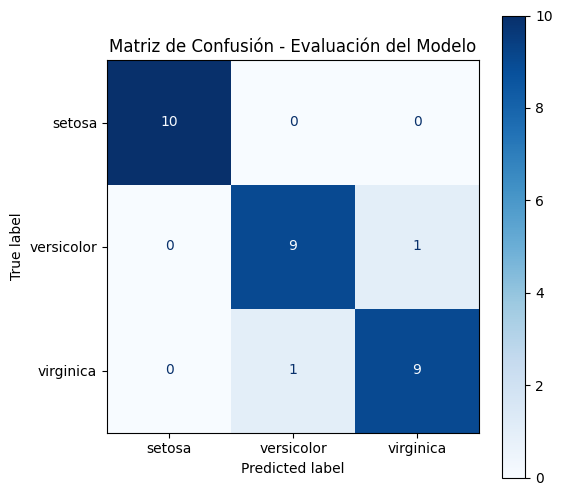

Report de arbol:


,precision,recall,f1-score,support
0,1.00,1.00,1.00,10.00
1,0.90,0.90,0.90,10.00
2,0.90,0.90,0.90,10.00
accuracy,0.93,0.93,0.93,0.93
macro avg,0.93,0.93,0.93,30.00
weighted avg,0.93,0.93,0.93,30.00


In [26]:
# Entrenamiento final
modelo_final = DecisionTreeClassifier(random_state=42)
modelo_final.fit(X_train_scaled, y_train)

# Predicción sobre el conjunto de prueba
y_pred = modelo_final.predict(X_test_scaled)

# Validación (Métricas)
precision_final = accuracy_score(y_test, y_pred)
print(f"Precisión final en el conjunto de prueba: {precision_final * 100:.2f}%\n")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)

# Graficamos la matriz
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - Evaluación del Modelo')
plt.show()



# Classification report
report_final= classification_report(y_pred, y_test, output_dict=True)



# Convertimos a DataFrame y transponemos para que las métricas sean columnas
print('Report de arbol:')
df_arbol = pd.DataFrame(report_final).transpose()
display(df_arbol.round(2))
